# Mint, lavender, and ambient stationary classifier

This notebook asks one deliberately narrow question:

> **Can complete stationary Cyranose trials distinguish ambient room air, mint, and lavender within the recorded pilot dataset?**

The analysis uses 15 trials per class. Every validation prediction comes from a model that did not receive any rows from that trial. The primary model follows the repository's established hierarchy:

1. ambient versus any recorded odor;
2. mint versus lavender using direction-normalized 32-sensor fingerprints.

A direct three-class regularized logistic model is retained as a diagnostic comparison. No mixture trials or spatial rasters are used here. Scores are classifier affinities, not concentrations or universally calibrated probabilities.


In [1]:
import sys
import site
from pathlib import Path
import csv
import hashlib
import json
import math
import re
from datetime import datetime, timezone

# Keep the working Conda stack internally consistent. A roaming user install
# contains NumPy 2.x, while this environment's compiled scientific packages use
# NumPy 1.26.
USER_SITE = Path(site.getusersitepackages()).resolve()
sys.path[:] = [
    entry for entry in sys.path
    if not entry or Path(entry).resolve() != USER_SITE
]

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (
            (candidate / "experiments").is_dir()
            and (candidate / "record_cyranose_reading_pose.py").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Run this notebook from inside the realsense-apriltag repository."
    )


ROOT = find_repo_root()
EXPERIMENT = (
    ROOT / "experiments" / "classifier" / "mint-lavender-ambient-pilot-01"
)
RAW = EXPERIMENT / "raw" / "pcnose"
MANIFEST_PATH = EXPERIMENT / "trial_manifest.csv"
ARTIFACT_DIR = EXPERIMENT / "frozen-models" / "mint-lavender-ambient-v1"

SENSORS = [f"S{i}" for i in range(1, 33)]
FEATURES = [f"x{i}" for i in range(1, 33)]
CLASS_ORDER = ["ambient", "mint", "lavender"]
COLORS = {
    "ambient": "#7A7A7A",
    "mint": "#3A9D73",
    "lavender": "#8066B3",
}
EXPECTED_PHASE_COUNTS = {1: 20, 3: 58, 6: 9, 7: 58}
ROLLING_ROWS = 3
MODEL_C = 0.1
RANDOM_STATE = 27
GO_NO_GO_BALANCED_ACCURACY = 0.80
GO_NO_GO_RECALL = 0.80

sns.set_theme(style="whitegrid", context="talk")
print("Repository:", ROOT)
print("Experiment:", EXPERIMENT.relative_to(ROOT))
print("Regularization fixed before lavender analysis: C =", MODEL_C)


Repository: C:\Users\dell-xps\Documents\realsense-apriltag
Experiment: experiments\classifier\mint-lavender-ambient-pilot-01
Regularization fixed before lavender analysis: C = 0.1


## 1. Dataset audit and immutable manifest

PCnose+ flag interpretation follows the existing classifier notebooks:

- **flag 1:** reference/purge phase;
- **flag 3:** active sample phase;
- **flags 6 and 7:** later protocol phases retained for audit but not used as classifier input.

For each trial, the median of the latter half of flag-1 readings is the 32-channel reference vector. Every flag-3 reading is converted to percentage change:

\[
x_i(t)=100\frac{S_i(t)-B_i}{B_i}.
\]

A three-row causal rolling median reduces isolated serial/sensor spikes. The trial-level fingerprint is the median of the latter half of the unsmoothed flag-3 response. Original files and repository copies are SHA-256 checked.


In [2]:
SOURCE_ROOTS = {
    "ambient": (
        ROOT
        / "experiments"
        / "classifier"
        / "mint-identity-pilot-01"
        / "raw"
        / "pcnose"
        / "blank"
    ),
    "mint": (
        ROOT
        / "experiments"
        / "classifier"
        / "mint-identity-pilot-01"
        / "raw"
        / "pcnose"
        / "mint"
    ),
    "lavender": Path(r"C:\Users\dell-xps\smell-tracing"),
}


def natural_trial_key(path):
    match = re.search(r"(\d+)", path.stem)
    return (int(match.group(1)) if match else math.inf, path.name)


def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


row_records = []
trial_records = []
manifest_records = []

for odor_class in CLASS_ORDER:
    files = sorted((RAW / odor_class).glob("*.csv"), key=natural_trial_key)
    for path in files:
        with path.open(newline="", encoding="utf-8-sig", errors="replace") as source:
            header_rows = list(csv.reader(source))[:2]

        instrument_line = header_rows[0][0] if header_rows and header_rows[0] else ""
        metadata_line = " | ".join(header_rows[1]) if len(header_rows) > 1 else ""
        serial_match = re.search(r"Serial Number:\s*([^+]+)", instrument_line)
        serial_number = serial_match.group(1).strip() if serial_match else ""
        recorded_date = (
            header_rows[1][0].strip()
            if len(header_rows) > 1 and header_rows[1]
            else ""
        )
        recorded_time = (
            header_rows[1][1].strip()
            if len(header_rows) > 1 and len(header_rows[1]) > 1
            else ""
        )

        frame = pd.read_csv(path, skiprows=2)
        frame["Flag"] = pd.to_numeric(frame["Flag"], errors="coerce")
        present_sensors = [sensor for sensor in SENSORS if sensor in frame.columns]
        sensor_frame = frame[present_sensors].apply(pd.to_numeric, errors="coerce")
        flag_counts = (
            frame["Flag"].dropna().astype(int).value_counts().sort_index().to_dict()
        )

        warnings = []
        if present_sensors != SENSORS:
            warnings.append(
                f"sensor columns: {len(present_sensors)}, expected {len(SENSORS)}"
            )
        for flag, expected in EXPECTED_PHASE_COUNTS.items():
            observed = int(flag_counts.get(flag, 0))
            if observed != expected:
                warnings.append(f"flag {flag}: {observed}, expected {expected}")

        baseline_rows = sensor_frame[frame["Flag"].eq(1)]
        sample_rows = sensor_frame[frame["Flag"].eq(3)]
        nonfinite_sample_values = int(
            (~np.isfinite(sample_rows.to_numpy(float))).sum()
        )
        if nonfinite_sample_values:
            warnings.append(
                f"nonfinite flag-3 sensor values: {nonfinite_sample_values}"
            )
        if len(baseline_rows) < 2:
            raise ValueError(f"{path.name}: insufficient flag-1 reference rows")
        if len(sample_rows) < 2:
            raise ValueError(f"{path.name}: insufficient flag-3 sample rows")
        if present_sensors != SENSORS:
            raise ValueError(f"{path.name}: expected all 32 sensor columns")

        late_baseline = baseline_rows.iloc[len(baseline_rows) // 2 :]
        baseline = late_baseline.median().to_numpy(float)
        sample = sample_rows.to_numpy(float)
        response = 100.0 * (sample - baseline) / baseline
        smoothed = (
            pd.DataFrame(response)
            .rolling(ROLLING_ROWS, min_periods=1)
            .median()
            .to_numpy()
        )

        trial_id = path.stem
        for sample_index, vector in enumerate(smoothed):
            row_records.append(
                {
                    "trial": trial_id,
                    "class": odor_class,
                    "recorded_date": recorded_date,
                    "sample_index": sample_index,
                    **{f"x{i + 1}": vector[i] for i in range(32)},
                }
            )

        late_sample = response[len(response) // 2 :]
        trial_vector = np.median(late_sample, axis=0)
        trial_records.append(
            {
                "trial": trial_id,
                "class": odor_class,
                "recorded_date": recorded_date,
                "recorded_time": recorded_time,
                "rms_pct": float(np.sqrt(np.mean(trial_vector**2))),
                **{f"x{i + 1}": trial_vector[i] for i in range(32)},
            }
        )

        source_path = SOURCE_ROOTS[odor_class] / path.name
        repository_hash = sha256(path)
        source_hash = sha256(source_path) if source_path.exists() else ""
        if source_hash and source_hash != repository_hash:
            warnings.append("repository copy hash differs from source")

        manifest_records.append(
            {
                "trial_id": trial_id,
                "class": odor_class,
                "recorded_date": recorded_date,
                "recorded_time": recorded_time,
                "repository_file": str(path.relative_to(ROOT)),
                "source_file": str(source_path),
                "sha256": repository_hash,
                "source_sha256": source_hash,
                "copy_hash_match": bool(source_hash == repository_hash),
                "serial_number": serial_number,
                "sensor_count": len(present_sensors),
                "unfiltered_metadata": "not filtered" in metadata_line.lower(),
                "total_rows": len(frame),
                "flag_0_rows": int(flag_counts.get(0, 0)),
                "flag_1_rows": int(flag_counts.get(1, 0)),
                "flag_3_rows": int(flag_counts.get(3, 0)),
                "flag_6_rows": int(flag_counts.get(6, 0)),
                "flag_7_rows": int(flag_counts.get(7, 0)),
                "nonfinite_flag_3_values": nonfinite_sample_values,
                "qc_status": "pass" if not warnings else "pass_with_warning",
                "qc_notes": "; ".join(warnings),
            }
        )

rows = pd.DataFrame(row_records)
trials = pd.DataFrame(trial_records)
manifest = pd.DataFrame(manifest_records).sort_values(["class", "trial_id"])

duplicate_counts = manifest["sha256"].map(manifest["sha256"].value_counts())
manifest["duplicate_sha_count"] = duplicate_counts
duplicate_mask = duplicate_counts.gt(1)
if duplicate_mask.any():
    manifest.loc[duplicate_mask, "qc_status"] = "review"
    manifest.loc[duplicate_mask, "qc_notes"] = manifest.loc[
        duplicate_mask, "qc_notes"
    ].str.cat(
        pd.Series(
            ["duplicate SHA-256 within dataset"] * int(duplicate_mask.sum()),
            index=manifest.index[duplicate_mask],
        ),
        sep="; ",
    ).str.strip("; ")

MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
manifest.to_csv(MANIFEST_PATH, index=False)

inventory = (
    manifest.groupby("class")
    .agg(
        trials=("trial_id", "count"),
        exposure_rows=("flag_3_rows", "sum"),
        qc_warnings=("qc_status", lambda values: int((values != "pass").sum())),
        copy_hash_matches=("copy_hash_match", "sum"),
    )
    .reindex(CLASS_ORDER)
)

assert len(manifest) == 45, f"Expected 45 trials; found {len(manifest)}"
assert inventory["trials"].eq(15).all(), "Expected 15 trials in every class"
assert manifest["sensor_count"].eq(32).all(), "Not every file has 32 sensors"
assert manifest["flag_3_rows"].eq(58).all(), "Not every file has 58 exposure rows"
assert manifest["copy_hash_match"].all(), "One or more repository copies differ"
assert not duplicate_mask.any(), "Duplicate raw files found within the dataset"

display(inventory)
display(
    manifest.loc[
        manifest["qc_status"] != "pass",
        ["trial_id", "class", "qc_status", "qc_notes"],
    ]
)
print("Saved manifest:", MANIFEST_PATH.relative_to(ROOT))


,trials,exposure_rows,qc_warnings,copy_hash_matches
class,,,,
ambient,15,870,2,15
mint,15,870,0,15
lavender,15,870,1,15


,trial_id,class,qc_status,qc_notes
9,blank-10,ambient,pass_with_warning,"flag 7: 57, expected 58"
2,blank-3,ambient,pass_with_warning,"flag 1: 21, expected 20"
38,lavender-9,lavender,pass_with_warning,"flag 1: 21, expected 20"


Saved manifest: experiments\classifier\mint-lavender-ambient-pilot-01\trial_manifest.csv


## 2. Fingerprints, magnitude, and session structure

The classifier should not be trusted merely because one odor produced a larger signal. The left panel therefore shows total response magnitude, while the right panel shows the relative 32-channel fingerprint.

PCA is included only as an exploratory two-dimensional view. It is fitted to all 45 trial summaries for visualization and is **not** used to calculate validation performance.


,min,median,max
class,,,
ambient,0.0119,0.0148,0.0333
mint,0.5302,0.9995,2.2133
lavender,0.1645,0.5096,0.9440


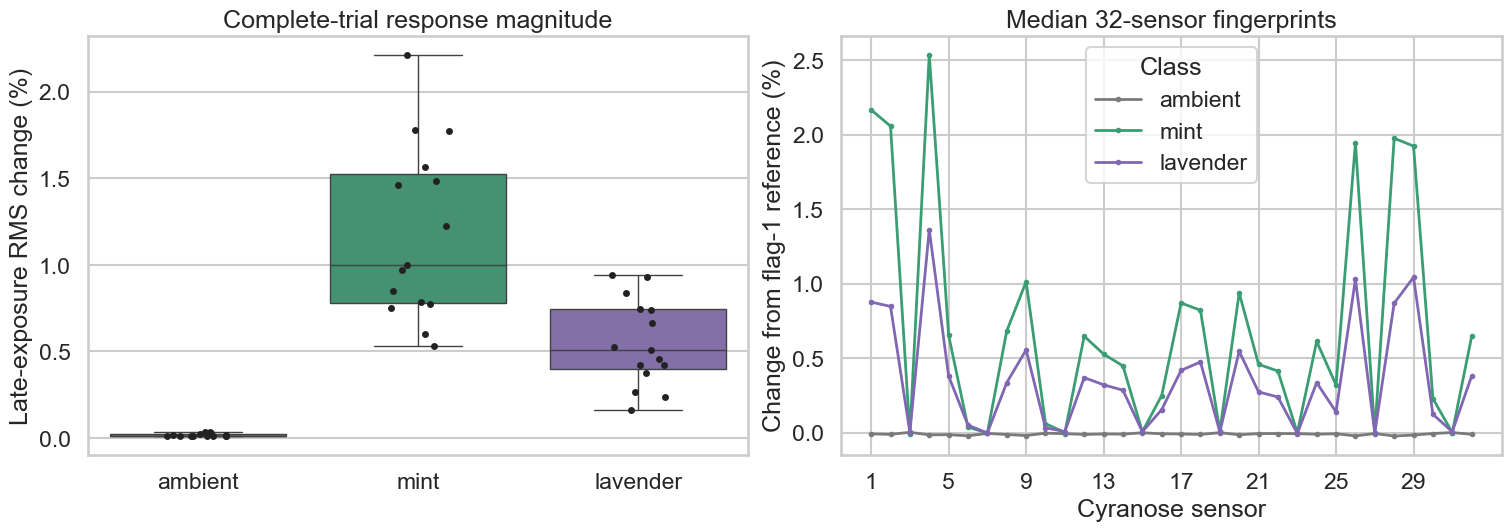

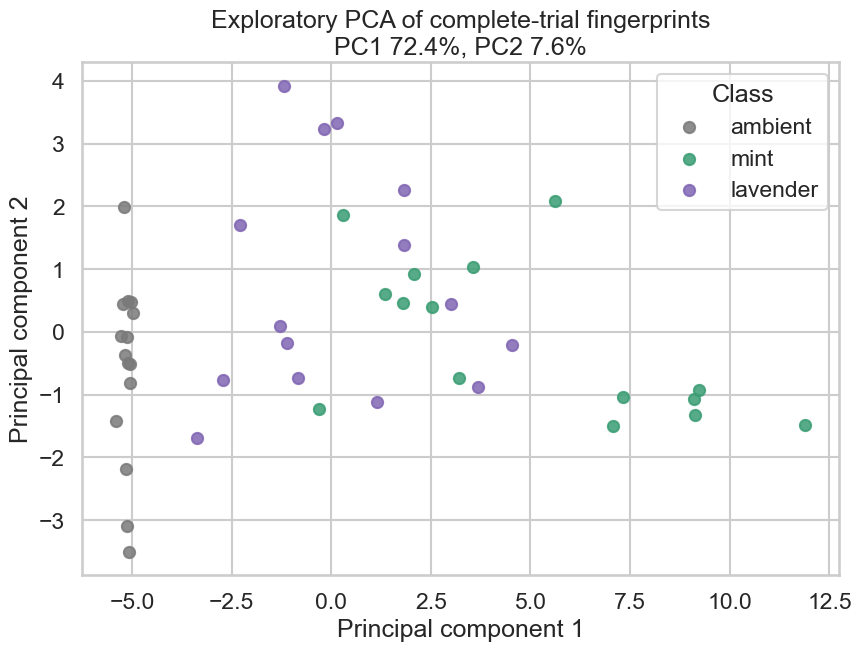

### Recording date by class

class,ambient,mint,lavender
recorded_date,,,
7/22/2026,0,10,0
7/23/2026,15,5,0
7/27/2026,0,0,15


In [3]:
magnitude_summary = (
    trials.groupby("class")["rms_pct"]
    .agg(["min", "median", "max"])
    .reindex(CLASS_ORDER)
)
display(magnitude_summary.style.format("{:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True)
sns.boxplot(
    data=trials,
    x="class",
    y="rms_pct",
    order=CLASS_ORDER,
    palette=COLORS,
    hue="class",
    legend=False,
    ax=axes[0],
)
sns.stripplot(
    data=trials,
    x="class",
    y="rms_pct",
    order=CLASS_ORDER,
    color="#222222",
    size=5,
    jitter=0.14,
    ax=axes[0],
)
axes[0].set_title("Complete-trial response magnitude")
axes[0].set_xlabel("")
axes[0].set_ylabel("Late-exposure RMS change (%)")

for odor_class in CLASS_ORDER:
    centroid = (
        trials.loc[trials["class"].eq(odor_class), FEATURES]
        .median()
        .to_numpy(float)
    )
    axes[1].plot(
        np.arange(1, 33),
        centroid,
        marker="o",
        markersize=3,
        linewidth=2,
        label=odor_class,
        color=COLORS[odor_class],
    )
axes[1].set_title("Median 32-sensor fingerprints")
axes[1].set_xlabel("Cyranose sensor")
axes[1].set_ylabel("Change from flag-1 reference (%)")
axes[1].set_xticks(np.arange(1, 33, 4))
axes[1].legend(title="Class")
plt.show()

trial_x_scaled = StandardScaler().fit_transform(trials[FEATURES])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_xy = pca.fit_transform(trial_x_scaled)
pca_frame = trials[["trial", "class", "recorded_date"]].copy()
pca_frame["PC1"] = pca_xy[:, 0]
pca_frame["PC2"] = pca_xy[:, 1]

fig, ax = plt.subplots(figsize=(8.5, 6.4), constrained_layout=True)
for odor_class in CLASS_ORDER:
    subset = pca_frame[pca_frame["class"].eq(odor_class)]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=65,
        alpha=0.85,
        label=odor_class,
        color=COLORS[odor_class],
    )
ax.set_title(
    "Exploratory PCA of complete-trial fingerprints\n"
    f"PC1 {pca.explained_variance_ratio_[0]:.1%}, "
    f"PC2 {pca.explained_variance_ratio_[1]:.1%}"
)
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.legend(title="Class")
plt.show()

date_class_table = pd.crosstab(trials["recorded_date"], trials["class"]).reindex(
    columns=CLASS_ORDER, fill_value=0
)
display(Markdown("### Recording date by class"))
display(date_class_table)


## 3. Complete-held-out-trial hierarchical validation

The five outer folds contain three held-out trials from each class. No row from a held-out trial is available while either stage is fitted.

- **Presence stage:** all active rows; ambient versus odor.
- **Identity stage:** latter-half odor rows only; mint versus lavender.
- **Identity input:** each 32-channel vector is divided by its L2 norm, reducing reliance on response strength.
- **Regularization:** `C=0.1`, locked from notebook 05 before lavender results were inspected.

For a held-out trial, row scores are summarized by their median. The three affinities are:

\[
\begin{aligned}
s_{ambient}&=1-p_{odor},\\
s_{mint}&=p_{odor}p_{mint\mid odor},\\
s_{lavender}&=p_{odor}(1-p_{mint\mid odor}).
\end{aligned}
\]

They sum to one but should not be interpreted as universal calibrated probabilities.


In [4]:
def make_logistic(multi_class=False):
    kwargs = {
        "C": MODEL_C,
        "max_iter": 5000,
        "random_state": RANDOM_STATE,
    }
    if multi_class:
        kwargs["class_weight"] = "balanced"
    return Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", LogisticRegression(**kwargs)),
        ]
    )


def equal_trial_class_weights(frame, target):
    target = np.asarray(target)
    trial_sizes = frame.groupby("trial").size().to_dict()
    trial_targets = (
        pd.DataFrame({"trial": frame["trial"].to_numpy(), "target": target})
        .drop_duplicates()
    )
    trials_per_class = trial_targets.groupby("target")["trial"].nunique().to_dict()
    weights = np.array(
        [
            1.0 / trial_sizes[trial] / trials_per_class[label]
            for trial, label in zip(frame["trial"], target)
        ],
        dtype=float,
    )
    return weights * len(weights) / weights.sum()


def l2_normalize(matrix):
    matrix = np.asarray(matrix, dtype=float)
    return matrix / np.maximum(
        np.linalg.norm(matrix, axis=1, keepdims=True), 1e-12
    )


presence_oof = np.full(len(rows), np.nan)
identity_oof = np.full(len(rows), np.nan)
fold_oof = np.full(len(rows), -1, dtype=int)

x_all = rows[FEATURES].to_numpy(float)
groups_all = rows["trial"].to_numpy()
labels_all = rows["class"].to_numpy()
outer = StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

for fold, (train_index, test_index) in enumerate(
    outer.split(x_all, labels_all, groups_all), start=1
):
    train_frame = rows.iloc[train_index].copy()
    test_frame = rows.iloc[test_index].copy()

    presence_y = train_frame["class"].ne("ambient").astype(int).to_numpy()
    presence_weights = equal_trial_class_weights(train_frame, presence_y)
    presence_model = make_logistic()
    presence_model.fit(
        train_frame[FEATURES].to_numpy(float),
        presence_y,
        model__sample_weight=presence_weights,
    )
    presence_oof[test_index] = presence_model.predict_proba(
        test_frame[FEATURES].to_numpy(float)
    )[:, 1]

    identity_train = train_frame.loc[
        train_frame["class"].ne("ambient")
        & train_frame["sample_index"].ge(29)
    ].copy()
    identity_y = identity_train["class"].eq("mint").astype(int).to_numpy()
    identity_weights = equal_trial_class_weights(identity_train, identity_y)
    identity_model = make_logistic()
    identity_model.fit(
        l2_normalize(identity_train[FEATURES]),
        identity_y,
        model__sample_weight=identity_weights,
    )
    identity_oof[test_index] = identity_model.predict_proba(
        l2_normalize(test_frame[FEATURES])
    )[:, 1]
    fold_oof[test_index] = fold

assert np.isfinite(presence_oof).all()
assert np.isfinite(identity_oof).all()
assert (fold_oof > 0).all()

row_oof = rows[["trial", "class", "sample_index"]].copy()
row_oof["fold"] = fold_oof
row_oof["odor_score"] = presence_oof
row_oof["mint_given_odor_score"] = identity_oof

hierarchical_records = []
for trial_id, frame in row_oof.groupby("trial", sort=False):
    late = frame[frame["sample_index"].ge(29)]
    odor_score = float(frame["odor_score"].median())
    mint_given_odor = float(late["mint_given_odor_score"].median())
    affinities = {
        "ambient": 1.0 - odor_score,
        "mint": odor_score * mint_given_odor,
        "lavender": odor_score * (1.0 - mint_given_odor),
    }
    ordered = np.array([affinities[label] for label in CLASS_ORDER])
    ranked = np.sort(ordered)
    hierarchical_records.append(
        {
            "trial": trial_id,
            "true_class": frame["class"].iloc[0],
            "fold": int(frame["fold"].iloc[0]),
            "odor_score": odor_score,
            "mint_given_odor_score": mint_given_odor,
            **{f"{label}_score": affinities[label] for label in CLASS_ORDER},
            "predicted_class": CLASS_ORDER[int(np.argmax(ordered))],
            "score_margin": float(ranked[-1] - ranked[-2]),
        }
    )

hierarchical_trials = pd.DataFrame(hierarchical_records).sort_values(
    ["true_class", "trial"]
)
display(hierarchical_trials.head())


,trial,true_class,fold,odor_score,mint_given_odor_score,ambient_score,mint_score,lavender_score,predicted_class,score_margin
0,blank-1,ambient,1,0.066771,1.0,0.933229,0.066771,0.0,ambient,0.866458
9,blank-10,ambient,2,0.093777,1.0,0.906223,0.093777,0.0,ambient,0.812447
10,blank-11,ambient,3,0.134979,1.0,0.865021,0.134979,0.0,ambient,0.730041
11,blank-12,ambient,4,0.134275,1.0,0.865725,0.134275,0.0,ambient,0.731450
12,blank-13,ambient,5,0.131826,1.0,0.868174,0.131826,0.0,ambient,0.736347


## 4. Direct three-class diagnostic

The diagnostic model receives one late-exposure median vector per complete trial and predicts ambient, mint, or lavender directly. It is useful as a simplicity check, but the hierarchy remains primary because it explicitly separates odor presence from odor identity.


In [5]:
trial_x = trials[FEATURES].to_numpy(float)
trial_y = trials["class"].to_numpy()
trial_splitter = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
direct_template = make_logistic(multi_class=True)
direct_probabilities = cross_val_predict(
    direct_template,
    trial_x,
    trial_y,
    cv=trial_splitter,
    method="predict_proba",
)
direct_classes = np.unique(trial_y)
direct_predictions = direct_classes[np.argmax(direct_probabilities, axis=1)]

direct_trials = trials[["trial", "class"]].copy()
direct_trials = direct_trials.rename(columns={"class": "true_class"})
for column, odor_class in enumerate(direct_classes):
    direct_trials[f"{odor_class}_score"] = direct_probabilities[:, column]
direct_trials["predicted_class"] = direct_predictions


## 5. Confusion matrix, recall, and decision gate

The headline unit is a complete trial. Row-level outputs are retained only to explain individual trial behavior.

Recall answers: “Out of the 15 true trials of this class, how many did the model recover?” Wilson intervals show the uncertainty created by having only 15 trials per class.


,model,accuracy,balanced_accuracy,macro_f1
0,Hierarchical,100.0%,100.0%,1.000
1,Direct,86.7%,86.7%,0.865


,model,class,correct,trials,recall,recall_95_low,recall_95_high
0,Hierarchical,ambient,15,15,100.0%,79.6%,100.0%
1,Hierarchical,mint,15,15,100.0%,79.6%,100.0%
2,Hierarchical,lavender,15,15,100.0%,79.6%,100.0%
3,Direct,ambient,15,15,100.0%,79.6%,100.0%
4,Direct,mint,12,15,80.0%,54.8%,93.0%
5,Direct,lavender,12,15,80.0%,54.8%,93.0%


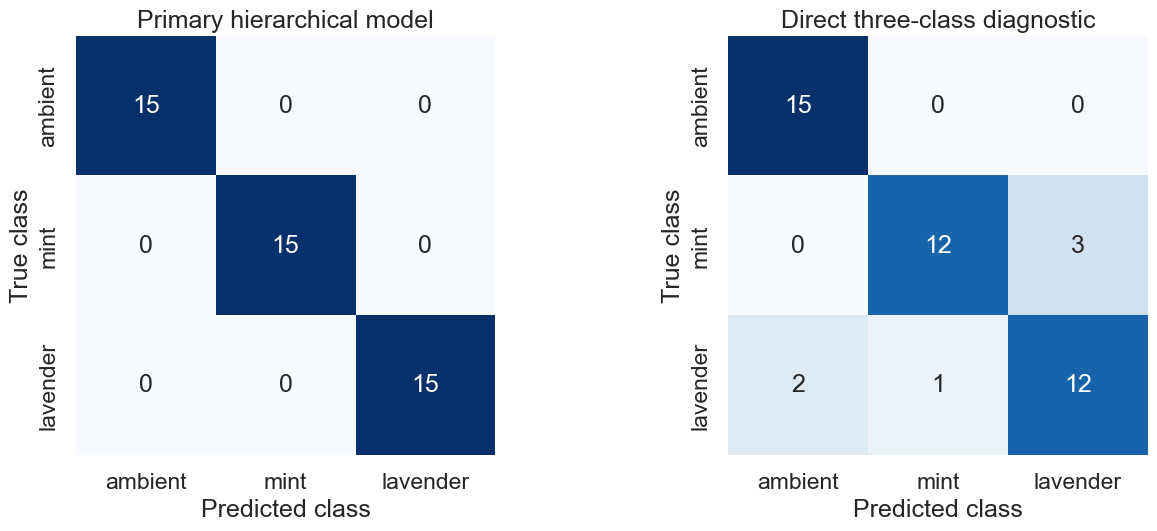

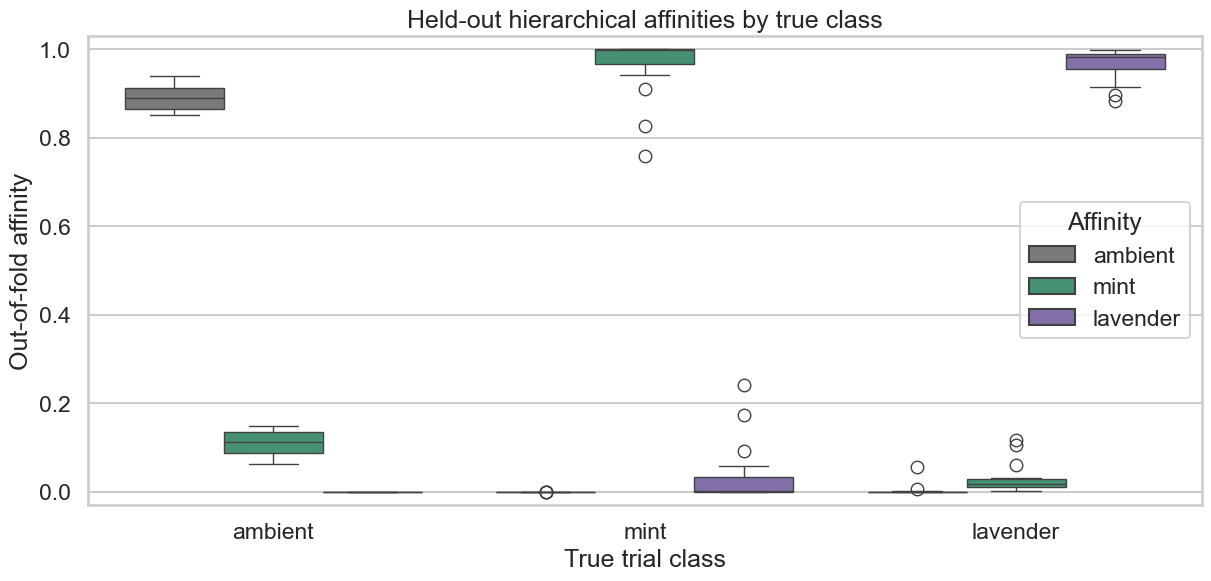

### Misclassified hierarchical trials

None.

### Predeclared pilot gate: **PASS**

- Hierarchical balanced accuracy: **100.0%** (required 80%)
- Lowest per-class recall: **100.0%** (required 80%)

In [6]:
def wilson_interval(successes, total, z=1.96):
    if total == 0:
        return (np.nan, np.nan)
    p = successes / total
    denominator = 1.0 + z**2 / total
    center = (p + z**2 / (2.0 * total)) / denominator
    half = (
        z
        * math.sqrt(
            p * (1.0 - p) / total + z**2 / (4.0 * total**2)
        )
        / denominator
    )
    return center - half, center + half


def summarize_model(name, frame):
    true = frame["true_class"].to_numpy()
    predicted = frame["predicted_class"].to_numpy()
    report = classification_report(
        true,
        predicted,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
    summary = {
        "model": name,
        "accuracy": accuracy_score(true, predicted),
        "balanced_accuracy": balanced_accuracy_score(true, predicted),
        "macro_f1": f1_score(true, predicted, average="macro"),
    }
    recalls = []
    for odor_class in CLASS_ORDER:
        total = int(np.sum(true == odor_class))
        successes = int(
            np.sum((true == odor_class) & (predicted == odor_class))
        )
        low, high = wilson_interval(successes, total)
        recalls.append(
            {
                "model": name,
                "class": odor_class,
                "correct": successes,
                "trials": total,
                "recall": report[odor_class]["recall"],
                "recall_95_low": low,
                "recall_95_high": high,
            }
        )
    return summary, recalls


hier_summary, hier_recalls = summarize_model(
    "Hierarchical", hierarchical_trials
)
direct_summary, direct_recalls = summarize_model("Direct", direct_trials)
model_summary = pd.DataFrame([hier_summary, direct_summary])
recall_table = pd.DataFrame(hier_recalls + direct_recalls)

display(model_summary.style.format({
    "accuracy": "{:.1%}",
    "balanced_accuracy": "{:.1%}",
    "macro_f1": "{:.3f}",
}))
display(
    recall_table.style.format({
        "recall": "{:.1%}",
        "recall_95_low": "{:.1%}",
        "recall_95_high": "{:.1%}",
    })
)

hier_matrix = confusion_matrix(
    hierarchical_trials["true_class"],
    hierarchical_trials["predicted_class"],
    labels=CLASS_ORDER,
)
direct_matrix = confusion_matrix(
    direct_trials["true_class"],
    direct_trials["predicted_class"],
    labels=CLASS_ORDER,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
for ax, matrix, title in [
    (axes[0], hier_matrix, "Primary hierarchical model"),
    (axes[1], direct_matrix, "Direct three-class diagnostic"),
]:
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        xticklabels=CLASS_ORDER,
        yticklabels=CLASS_ORDER,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
plt.show()

score_columns = [f"{label}_score" for label in CLASS_ORDER]
score_long = hierarchical_trials.melt(
    id_vars=["trial", "true_class"],
    value_vars=score_columns,
    var_name="score_type",
    value_name="affinity",
)
score_long["score_type"] = score_long["score_type"].str.replace(
    "_score", "", regex=False
)

fig, ax = plt.subplots(figsize=(12, 5.7), constrained_layout=True)
sns.boxplot(
    data=score_long,
    x="true_class",
    y="affinity",
    hue="score_type",
    order=CLASS_ORDER,
    hue_order=CLASS_ORDER,
    palette=COLORS,
    ax=ax,
)
ax.set_title("Held-out hierarchical affinities by true class")
ax.set_xlabel("True trial class")
ax.set_ylabel("Out-of-fold affinity")
ax.set_ylim(-0.03, 1.03)
ax.legend(title="Affinity")
plt.show()

hier_recall_values = (
    recall_table.loc[recall_table["model"].eq("Hierarchical")]
    .set_index("class")["recall"]
    .reindex(CLASS_ORDER)
)
gate_pass = bool(
    hier_summary["balanced_accuracy"] >= GO_NO_GO_BALANCED_ACCURACY
    and hier_recall_values.ge(GO_NO_GO_RECALL).all()
)

mistakes = hierarchical_trials.loc[
    hierarchical_trials["true_class"]
    != hierarchical_trials["predicted_class"],
    [
        "trial",
        "true_class",
        "predicted_class",
        "ambient_score",
        "mint_score",
        "lavender_score",
        "score_margin",
    ],
]
display(Markdown("### Misclassified hierarchical trials"))
display(mistakes if len(mistakes) else Markdown("None."))

gate_text = "PASS" if gate_pass else "DO NOT FREEZE"
display(
    Markdown(
        f"### Predeclared pilot gate: **{gate_text}**\n\n"
        f"- Hierarchical balanced accuracy: "
        f"**{hier_summary['balanced_accuracy']:.1%}** "
        f"(required {GO_NO_GO_BALANCED_ACCURACY:.0%})\n"
        f"- Lowest per-class recall: **{hier_recall_values.min():.1%}** "
        f"(required {GO_NO_GO_RECALL:.0%})"
    )
)


## 6. Session limitation

Complete-trial validation prevents leakage between rows from the same file. It does **not** remove a recording-day confound when an odor class exists on only one date.

In this dataset, lavender was collected after the existing mint and ambient trials. There is therefore no valid leave-one-date-out split containing all three classes. Even a perfect confusion matrix would establish closed-panel separation within these files, not session-invariant lavender identity.


In [7]:
lavender_dates = sorted(
    trials.loc[trials["class"].eq("lavender"), "recorded_date"].unique()
)
other_dates = sorted(
    trials.loc[trials["class"].ne("lavender"), "recorded_date"].unique()
)

session_confounded = not bool(set(lavender_dates) & set(other_dates))
display(
    Markdown(
        f"- Lavender recording dates: `{lavender_dates}`\n"
        f"- Mint/ambient recording dates: `{other_dates}`\n"
        f"- Shared lavender versus non-lavender date: "
        f"**{'yes' if not session_confounded else 'no'}**\n\n"
        + (
            "**Interpretation:** odor label and lavender recording session are "
            "confounded. Cross-session identity remains untested."
            if session_confounded
            else
            "**Interpretation:** at least one recording date contains both "
            "lavender and another primary class."
        )
    )
)


- Lavender recording dates: `['7/27/2026']`
- Mint/ambient recording dates: `['7/22/2026', '7/23/2026']`
- Shared lavender versus non-lavender date: **no**

**Interpretation:** odor label and lavender recording session are confounded. Cross-session identity remains untested.

## 7. Freeze the closed-panel pilot only if the gate passes

Freezing prevents later spatial or mixture results from silently changing this classifier. The bundle records the preprocessing, sensor order, fitted models, validation summary, data-manifest digest, limitations, and model checksum.


In [8]:
def fit_final_bundle():
    presence_y = rows["class"].ne("ambient").astype(int).to_numpy()
    presence_weights = equal_trial_class_weights(rows, presence_y)
    final_presence = make_logistic()
    final_presence.fit(
        rows[FEATURES].to_numpy(float),
        presence_y,
        model__sample_weight=presence_weights,
    )

    identity_data = rows.loc[
        rows["class"].ne("ambient") & rows["sample_index"].ge(29)
    ].copy()
    identity_y = identity_data["class"].eq("mint").astype(int).to_numpy()
    identity_weights = equal_trial_class_weights(identity_data, identity_y)
    final_identity = make_logistic()
    final_identity.fit(
        l2_normalize(identity_data[FEATURES]),
        identity_y,
        model__sample_weight=identity_weights,
    )

    final_direct = clone(direct_template)
    final_direct.fit(trial_x, trial_y)

    return {
        "bundle_name": "mint-lavender-ambient-v1",
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "sensor_order": SENSORS,
        "feature_order": FEATURES,
        "class_order": CLASS_ORDER,
        "baseline_phase": 1,
        "sample_phase": 3,
        "baseline_rule": "median of latter half of flag-1 rows",
        "sample_rule": "percentage change from per-trial baseline",
        "rolling_median_rows": ROLLING_ROWS,
        "identity_min_sample_index": 29,
        "regularization_C": MODEL_C,
        "presence_model": final_presence,
        "identity_model": final_identity,
        "direct_model": final_direct,
        "limitations": [
            "closed-panel stationary pilot",
            "lavender class is confounded with recording date",
            "no mixture training or validation",
            "scores are not concentrations or universal calibrated probabilities",
        ],
    }


def score_trial_frame(bundle, frame):
    x = frame[FEATURES].to_numpy(float)
    odor_score = float(np.median(bundle["presence_model"].predict_proba(x)[:, 1]))
    late = frame[frame["sample_index"].ge(bundle["identity_min_sample_index"])]
    mint_given_odor = float(np.median(
        bundle["identity_model"].predict_proba(
            l2_normalize(late[FEATURES])
        )[:, 1]
    ))
    return np.array(
        [
            1.0 - odor_score,
            odor_score * mint_given_odor,
            odor_score * (1.0 - mint_given_odor),
        ]
    )


if gate_pass:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    bundle = fit_final_bundle()
    model_path = ARTIFACT_DIR / "model.joblib"
    joblib.dump(bundle, model_path)

    reloaded = joblib.load(model_path)
    max_reload_difference = 0.0
    for _, trial_frame in rows.groupby("trial"):
        before = score_trial_frame(bundle, trial_frame)
        after = score_trial_frame(reloaded, trial_frame)
        max_reload_difference = max(
            max_reload_difference,
            float(np.max(np.abs(before - after))),
        )
    assert max_reload_difference <= 1e-12

    model_sha256 = sha256(model_path)
    manifest_sha256 = sha256(MANIFEST_PATH)
    validation_record = {
        "hierarchical_accuracy": float(hier_summary["accuracy"]),
        "hierarchical_balanced_accuracy": float(
            hier_summary["balanced_accuracy"]
        ),
        "hierarchical_macro_f1": float(hier_summary["macro_f1"]),
        "per_class_recall": {
            odor_class: float(hier_recall_values.loc[odor_class])
            for odor_class in CLASS_ORDER
        },
        "direct_accuracy": float(direct_summary["accuracy"]),
        "direct_balanced_accuracy": float(
            direct_summary["balanced_accuracy"]
        ),
        "direct_macro_f1": float(direct_summary["macro_f1"]),
    }
    config = {
        "bundle_name": bundle["bundle_name"],
        "created_utc": bundle["created_utc"],
        "training_trials": 45,
        "trials_per_class": 15,
        "sensor_order": SENSORS,
        "class_order": CLASS_ORDER,
        "baseline_phase": 1,
        "sample_phase": 3,
        "baseline_rule": bundle["baseline_rule"],
        "sample_rule": bundle["sample_rule"],
        "rolling_median_rows": ROLLING_ROWS,
        "identity_min_sample_index": 29,
        "regularization_C": MODEL_C,
        "manifest_sha256": manifest_sha256,
        "model_sha256": model_sha256,
        "reload_max_absolute_difference": max_reload_difference,
        "validation": validation_record,
        "limitations": bundle["limitations"],
    }
    (ARTIFACT_DIR / "config.json").write_text(
        json.dumps(config, indent=2), encoding="utf-8"
    )

    recall_lines = "\n".join(
        f"  - {odor_class}: {hier_recall_values.loc[odor_class]:.1%};"
        for odor_class in CLASS_ORDER
    )
    model_card = f"""# Mint, lavender, and ambient v1

Status: accepted closed-panel stationary pilot.

Training data:

- 15 ambient trials;
- 15 mint trials;
- 15 lavender trials;
- 32 unfiltered Cyranose 320 channels;
- complete trials held out during five-fold validation.

Primary held-out-trial results:

- accuracy: {hier_summary['accuracy']:.1%};
- balanced accuracy: {hier_summary['balanced_accuracy']:.1%};
- macro F1: {hier_summary['macro_f1']:.3f};
- per-class recall:
{recall_lines}

The model is hierarchical: ambient-versus-odor followed by direction-normalized
mint-versus-lavender identity. Regularization C={MODEL_C} was fixed from the
earlier classifier pilot before lavender performance was inspected.

Limitations:

- lavender was recorded on a later date than the existing mint and ambient
  trials, so lavender identity is confounded with recording session;
- this is a stationary closed-panel result;
- no odor mixture was used for training or validation;
- scores are affinities, not concentrations or universal calibrated
  probabilities;
- spatial transfer has not been tested.

Model SHA-256: `{model_sha256}`
Manifest SHA-256: `{manifest_sha256}`
Reload maximum absolute difference: `{max_reload_difference:.3e}`
"""
    (ARTIFACT_DIR / "MODEL_CARD.md").write_text(model_card, encoding="utf-8")

    display(
        Markdown(
            f"Frozen bundle: `{ARTIFACT_DIR.relative_to(ROOT)}`  \n"
            f"Model SHA-256: `{model_sha256}`  \n"
            f"Reload maximum absolute difference: "
            f"`{max_reload_difference:.3e}`"
        )
    )
else:
    display(
        Markdown(
            "**No model was frozen.** The predeclared complete-trial gate did "
            "not pass; diagnose the stationary fingerprints before any spatial "
            "or mixture application."
        )
    )


Frozen bundle: `experiments\classifier\mint-lavender-ambient-pilot-01\frozen-models\mint-lavender-ambient-v1`  
Model SHA-256: `056681963a5e36ad8ae4080934a76792bcd919794a6ca63e957677cc2f7d1662`  
Reload maximum absolute difference: `0.000e+00`

## 8. Result and next decision

The cell below generates the restrained interpretation used in the repository documentation. Regardless of performance, the next scientific decision remains separate from mixture or spatial mapping: first determine whether the three pure stationary classes are distinguishable without trial leakage.


In [9]:
recall_sentence = ", ".join(
    f"{odor_class} {hier_recall_values.loc[odor_class]:.1%}"
    for odor_class in CLASS_ORDER
)

if gate_pass:
    conclusion = (
        f"The primary hierarchical model passed the predeclared closed-panel "
        f"pilot gate with {hier_summary['balanced_accuracy']:.1%} balanced "
        f"accuracy. Per-class recall was {recall_sentence}. The direct "
        f"three-class diagnostic achieved "
        f"{direct_summary['balanced_accuracy']:.1%} balanced accuracy. "
        "This supports pure-class separability within the recorded files and "
        "justifies freezing the pilot. It does not yet establish "
        "session-invariant lavender recognition, moving-scan transfer, or "
        "zero-shot mixture decomposition."
    )
else:
    conclusion = (
        f"The primary hierarchical model did not pass the predeclared pilot "
        f"gate. Balanced accuracy was "
        f"{hier_summary['balanced_accuracy']:.1%}; per-class recall was "
        f"{recall_sentence}. The fingerprints should be diagnosed before "
        "collecting or modeling mixtures."
    )

display(Markdown(conclusion))


The primary hierarchical model passed the predeclared closed-panel pilot gate with 100.0% balanced accuracy. Per-class recall was ambient 100.0%, mint 100.0%, lavender 100.0%. The direct three-class diagnostic achieved 86.7% balanced accuracy. This supports pure-class separability within the recorded files and justifies freezing the pilot. It does not yet establish session-invariant lavender recognition, moving-scan transfer, or zero-shot mixture decomposition.